In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, 
    classification_report, 
    ConfusionMatrixDisplay, 
    mean_squared_error, 
    make_scorer, mean_squared_error,  
    mean_absolute_error, r2_score,
    confusion_matrix,
    matthews_corrcoef,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np

In [2]:
eunice = pd.read_csv("../eunice_csv_files/eunice_combined_npml.csv.gz")
nomin = pd.read_csv("../nomin_csv_files/combined_npml_n.csv.gz")
prithvi = pd.read_csv("../prithvi_csv_files/prithvi_combined_npml.csv.gz")
jade = pd.read_csv("../jade_csv_files/npml_jade_features.csv")

print(f"eunice  {eunice.shape}  id0={eunice['id'].iloc[0]}")
print(f"nomin   {nomin.shape}  id0={nomin['id'].iloc[0]}")
print(f"prithvi {prithvi.shape}  id0={prithvi['id'].iloc[0]}")
print(f"jade    {jade.shape}  id0={jade['id'].iloc[0]}")

eunice  (159697, 7)  id0=3033789_npml_0
nomin   (159697, 11)  id0=3033789_npml_0
prithvi (159697, 8)  id0=3033789_npml_0
jade    (159697, 5)  id0=3033789_npml_0


In [3]:
df = eunice.merge(nomin, on="id")
df = df.merge(prithvi, on="id")
df = df.merge(jade, on="id")

print(df.shape)

(159697, 28)


In [4]:
df

,id,ED,HWP,ND80,PPR,SCA,LQ80,tail_slope_no_pz,current_kurtosis,time_to_peak,...,tdrift50,tdrift99,tfr,peak_count,gbn,bpr,AvsE,GradAreaRatio,GradWidthMain,HFER
0,3033789_npml_0,3405,2090.0,0.0,0.694995,0.034962,-3.234871e+05,-10061.013124,6.674751,83,...,28.0,83.0,0.153772,5,1.161357,0.055796,0.464572,1.000000e+00,69.0,0.035655
1,3033790_npml_0,3406,2165.0,0.0,0.702777,0.035541,-2.097532e+05,-9089.512080,10.563529,180,...,71.0,180.0,0.142348,3,1.542807,0.062473,0.545391,1.000000e+00,50.0,0.036721
2,3033791_npml_0,3408,2129.0,0.0,0.699074,0.035238,-2.425070e+05,-9449.901755,5.231941,185,...,76.0,185.0,0.144746,6,1.171004,0.049921,0.369508,1.000000e+00,91.0,0.036480
3,3033792_npml_0,3411,2125.0,0.0,0.701728,0.035928,-2.223822e+05,-8567.556832,7.421443,201,...,101.0,201.0,0.135823,10,2.442536,0.053420,0.407709,1.000000e+00,74.0,0.037065
4,3033793_npml_0,3405,2002.0,0.0,0.684008,0.035634,-2.887550e+05,-10081.558061,8.552893,96,...,66.0,96.0,0.155597,24,1.367881,0.061533,0.514774,1.000000e+00,60.0,0.037231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159692,3193481_npml_2,3408,2046.0,0.0,0.693882,0.034458,-8.314132e+05,-10371.604799,7.796771,77,...,54.0,77.0,0.149046,2,2.085564,0.059918,0.498966,9.614787e+01,78.0,0.034546
159693,3193482_npml_2,3411,2060.0,0.0,0.696157,0.034467,-1.789650e+06,-10700.698164,10.240402,94,...,76.0,93.0,0.143292,1,1.029563,0.062920,0.555909,3.904286e+12,94.0,0.034369
159694,3193483_npml_2,3409,2082.0,0.0,0.697220,0.034344,-1.315494e+06,-10687.382341,10.704435,86,...,60.0,85.0,0.146062,1,1.433963,0.064889,0.578813,2.948667e+12,85.0,0.034125
159695,3193484_npml_2,3405,2062.0,0.0,0.693403,0.034225,-2.350121e+06,-10623.611465,8.239963,65,...,28.0,65.0,0.154574,1,1.453343,0.060919,0.514199,1.933387e+02,60.0,0.034301


In [5]:
df.to_csv("combined_npml_features.csv.gz", index=False, compression="gzip")

In [6]:
npml_file = pd.read_csv("combined_npml_features.csv.gz")
npml_file

,id,ED,HWP,ND80,PPR,SCA,LQ80,tail_slope_no_pz,current_kurtosis,time_to_peak,...,tdrift50,tdrift99,tfr,peak_count,gbn,bpr,AvsE,GradAreaRatio,GradWidthMain,HFER
0,3033789_npml_0,3405,2090.0,0.0,0.694995,0.034962,-3.234871e+05,-10061.013124,6.674751,83,...,28.0,83.0,0.153772,5,1.161357,0.055796,0.464572,1.000000e+00,69.0,0.035655
1,3033790_npml_0,3406,2165.0,0.0,0.702777,0.035541,-2.097532e+05,-9089.512080,10.563529,180,...,71.0,180.0,0.142348,3,1.542807,0.062473,0.545391,1.000000e+00,50.0,0.036721
2,3033791_npml_0,3408,2129.0,0.0,0.699074,0.035238,-2.425070e+05,-9449.901755,5.231941,185,...,76.0,185.0,0.144746,6,1.171004,0.049921,0.369508,1.000000e+00,91.0,0.036480
3,3033792_npml_0,3411,2125.0,0.0,0.701728,0.035928,-2.223822e+05,-8567.556832,7.421443,201,...,101.0,201.0,0.135823,10,2.442536,0.053420,0.407709,1.000000e+00,74.0,0.037065
4,3033793_npml_0,3405,2002.0,0.0,0.684008,0.035634,-2.887550e+05,-10081.558061,8.552893,96,...,66.0,96.0,0.155597,24,1.367881,0.061533,0.514774,1.000000e+00,60.0,0.037231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159692,3193481_npml_2,3408,2046.0,0.0,0.693882,0.034458,-8.314132e+05,-10371.604799,7.796771,77,...,54.0,77.0,0.149046,2,2.085564,0.059918,0.498966,9.614787e+01,78.0,0.034546
159693,3193482_npml_2,3411,2060.0,0.0,0.696157,0.034467,-1.789650e+06,-10700.698164,10.240402,94,...,76.0,93.0,0.143292,1,1.029563,0.062920,0.555909,3.904286e+12,94.0,0.034369
159694,3193483_npml_2,3409,2082.0,0.0,0.697220,0.034344,-1.315494e+06,-10687.382341,10.704435,86,...,60.0,85.0,0.146062,1,1.433963,0.064889,0.578813,2.948667e+12,85.0,0.034125
159695,3193484_npml_2,3405,2062.0,0.0,0.693403,0.034225,-2.350121e+06,-10623.611465,8.239963,65,...,28.0,65.0,0.154574,1,1.453343,0.060919,0.514199,1.933387e+02,60.0,0.034301


In [ ]:
train_df = pd.read_csv("combined_train_with_labels.csv.gz")
train_df

,id,energy_label,psd_label_low_avse,psd_label_high_avse,psd_label_dcr,psd_label_lq,tp0,ED,HWP,LQ80,...,tdrift50,tdrift99,tfr,peak_count,gbn,bpr,AvsE,GradAreaRatio,GradWidthMain,HFER
0,0_train_0,582.364295,False,True,True,True,957,3409.0,2120.0,-635333.796311,...,65.0,85.0,0.142357,3,1.198436,0.059642,0.519805,1.000000,76.0,0.034772
1,1_train_0,250.159995,False,True,True,True,948,3404.0,2004.0,-289756.893085,...,60.0,87.0,0.151160,3,1.381123,0.061975,0.531775,1.000000,46.0,0.037621
2,2_train_0,1212.323954,False,True,False,True,965,3411.0,2125.0,-379843.029134,...,67.0,95.0,0.142606,3,1.361857,0.050813,0.343676,1.000000,90.0,0.035552
3,3_train_0,240.878110,False,True,True,False,927,3408.0,2098.0,-252673.626844,...,90.0,116.0,0.133192,2,1.165654,0.062954,0.483144,1.000000,56.0,0.035093
4,4_train_0,285.124189,False,True,True,False,958,3406.0,2037.0,-317761.453582,...,61.0,94.0,0.145504,7,1.390918,0.055013,0.377738,1.000000,53.0,0.035971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039995,1039995_train_15,210.834626,True,True,True,True,949,3403.0,2048.0,-240759.341995,...,55.0,90.0,0.151747,6,1.008092,0.062825,0.573645,33.442724,69.0,0.035228
1039996,1039996_train_15,380.170340,True,True,True,True,949,3404.0,2045.0,-417622.302428,...,57.0,79.0,0.150305,3,1.245492,0.062706,0.564955,58.862967,71.0,0.034669
1039997,1039997_train_15,370.109563,False,True,True,True,947,3409.0,2063.0,-407730.168602,...,77.0,102.0,0.142950,2,1.149456,0.062153,0.473789,143.746154,79.0,0.034553
1039998,1039998_train_15,98.258524,True,True,True,False,921,3400.0,2001.0,-116570.568893,...,71.0,92.0,0.153135,5,1.192639,0.065264,0.572606,1.000000,42.0,0.039377


In [9]:
classification_label_cols = [
    "psd_label_lq",
    "psd_label_high_avse",
    "psd_label_low_avse",
    "psd_label_dcr"
]

non_label_cols = ["id", "energy_label"]

feature_cols = [col for col in train_df.columns if col not in classification_label_cols+non_label_cols]
print("Number of features:",len(feature_cols))
print("Feature columns:", feature_cols)

Number of features: 27
Feature columns: ['tp0', 'ED', 'HWP', 'LQ80', 'PPR', 'SCA', 'ND80', 'current_skewness', 'tail_slope_no_pz', 'spectral_centroid_power', 'current_kurtosis', 'tail_slope', 'total_power', 'time_to_main_peak', 'time_to_peak', 'current_width', 'tdrift10', 'tdrift50', 'tdrift99', 'tfr', 'peak_count', 'gbn', 'bpr', 'AvsE', 'GradAreaRatio', 'GradWidthMain', 'HFER']


In [22]:
X_train = train_df[feature_cols]
y_train_high_avse = train_df["psd_label_high_avse"]
y_train_low_avse = train_df["psd_label_low_avse"]
y_train_dcr = train_df["psd_label_dcr"]
y_train_lq = train_df["psd_label_lq"]
y_train_energy = train_df["energy_label"]

X_npml = df[feature_cols]
npml_ids = df["id"]

## Classification

### high_avse classification - XGBoost

In [16]:
high_avse_xgb_threshold = 0.7

high_avse_xgb = XGBClassifier(
    subsample=1.0,
    scale_pos_weight=0.5,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.3,
    gamma=0.1,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

high_avse_xgb.fit(X_train, y_train_high_avse)

y_probs_high_avse = high_avse_xgb.predict_proba(X_npml)[:, 1]
pred_high_avse = (y_probs_high_avse >= high_avse_xgb_threshold).astype(int)

### lq classification - Random Forest

In [17]:
best_threshold_lq = 0.42

rf_pipe_lq = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipe_lq.fit(X_train, y_train_lq)

y_probs_lq = rf_pipe_lq.predict_proba(X_npml)[:, 1]
pred_lq = (y_probs_lq >= best_threshold_lq).astype(int)

### low_avse classification - Random Forest

In [ ]:
rf_low_avse = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_low_avse.fit(X_train, y_train_low_avse)

pred_low_avse = rf_low_avse.predict(X_npml)

In [30]:
pred_low_avse = pred_low_avse.astype(int)

### dcr classification - Neural Network

In [19]:
dcr_nn_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),   
        activation="relu",
        batch_size=1024,
        max_iter=20,
        alpha=1e-4,                    
        learning_rate="adaptive",
        random_state=42,
        verbose=True
    )),
])

dcr_nn_pipe.fit(X_train, y_train_dcr)

dcr_probs = dcr_nn_pipe.predict_proba(X_npml)[:, 1]
dcr_preds = (dcr_probs >= 0.5).astype(int)

Iteration 1, loss = 0.08548559
Iteration 2, loss = 0.07094193
Iteration 3, loss = 0.06826596
Iteration 4, loss = 0.06654940
Iteration 5, loss = 0.06545810
Iteration 6, loss = 0.06473697
Iteration 7, loss = 0.06410945
Iteration 8, loss = 0.06350922
Iteration 9, loss = 0.06311153
Iteration 10, loss = 0.06277328
Iteration 11, loss = 0.06234661
Iteration 12, loss = 0.06205369
Iteration 13, loss = 0.06186942
Iteration 14, loss = 0.06160711
Iteration 15, loss = 0.06139078
Iteration 16, loss = 0.06110449
Iteration 17, loss = 0.06095640
Iteration 18, loss = 0.06075969
Iteration 19, loss = 0.06049196
Iteration 20, loss = 0.06042333


/opt/anaconda3/envs/xgb/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


## Regression

### LightGBM Regression

In [23]:
lgb_model = lgb.LGBMRegressor(
    learning_rate=0.03,
    n_estimators=5000,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train_energy)

y_pred_lgb = lgb_model.predict(X_npml)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6354
[LightGBM] [Info] Number of data points in the train set: 1040000, number of used features: 27
[LightGBM] [Info] Start training from score 638.163302


### XGBoost Regression

In [25]:
xgb_regressor_model = XGBRegressor(
    subsample=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    n_estimators=800,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=0.7,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_regressor_model.fit(X_train, y_train_energy)

y_pred_xgb = xgb_regressor_model.predict(X_npml)

## Combine Predictions

In [35]:
pred_df = pd.DataFrame({
    "id": npml_ids,
    "pred_lq_npml": pred_lq,
    "pred_high_avse_npml": pred_high_avse,
    "pred_low_avse_npml": pred_low_avse,
    "pred_dcr_npml": dcr_preds,
    "pred_energy_lightgbm_npml": y_pred_lgb,
    "pred_energy_xgb_npml": y_pred_xgb
})

# SSE = 1 only if all four predicted labels are 1, else 0
pred_df["SSE"] = (
    (pred_df["pred_lq_npml"] == 1) &
    (pred_df["pred_high_avse_npml"] == 1) &
    (pred_df["pred_low_avse_npml"] == 1) &
    (pred_df["pred_dcr_npml"] == 1)
).astype(int)

pred_df.to_csv("npml_predictions.csv", index=False)

In [ ]:
pred_df = pd.read_csv("npml_predictions.csv")
pred_df

,id,pred_lq_npml,pred_high_avse_npml,pred_low_avse_npml,pred_dcr_npml,pred_energy_lightgbm_npml,pred_energy_xgb_npml,SSE
0,3033789_npml_0,0,1,0,1,302.768943,301.74347,0
1,3033790_npml_0,0,1,0,1,225.250495,225.31955,0
2,3033791_npml_0,0,1,0,1,240.973070,242.80298,0
3,3033792_npml_0,0,1,0,1,222.921021,222.64426,0
4,3033793_npml_0,1,1,0,1,238.653014,238.19229,0
...,...,...,...,...,...,...,...,...
159692,3193481_npml_2,1,1,0,1,739.106486,733.15220,0
159693,3193482_npml_2,1,1,1,1,1584.444720,1590.29300,1
159694,3193483_npml_2,1,1,0,1,1170.963446,1181.37870,0
159695,3193484_npml_2,0,1,0,1,2082.256502,2108.27860,0


In [23]:
def plot_energy_spectrum(
    y_pred,
    model=None,
    cut=False,
    add_peaks=False,                 # <-- option to add vertical lines for known peaks
):
    bins = np.linspace(0, 4000, 400)

    plt.figure(figsize=(8, 4))
    plt.hist(
        y_pred,
        bins=bins,
        histtype="step",
        log=True,
        label="Predicted Energy (SSE Events)" if cut else "Predicted Energy (All Events)",
    )

    # optional vertical dashed lines
    if add_peaks:
        peak_energy = 2615  # keV
        peak_label = f"~{peak_energy:g} keV"
        ymin, ymax = plt.ylim()
        plt.axvline(peak_energy, linestyle="--", linewidth=1, color="red")
        plt.text(peak_energy + 10, ymax * 0.7, peak_label, va="top", fontsize=9)

    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts (log scale)")
    if model:
        plt.title(f"Energy Spectrum of NPML Dataset ({model})" + (" — PSD cut" if cut else ""))
    else:
        plt.title("Energy Spectrum of NPML Dataset" + (" — PSD cut" if cut else ""))

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

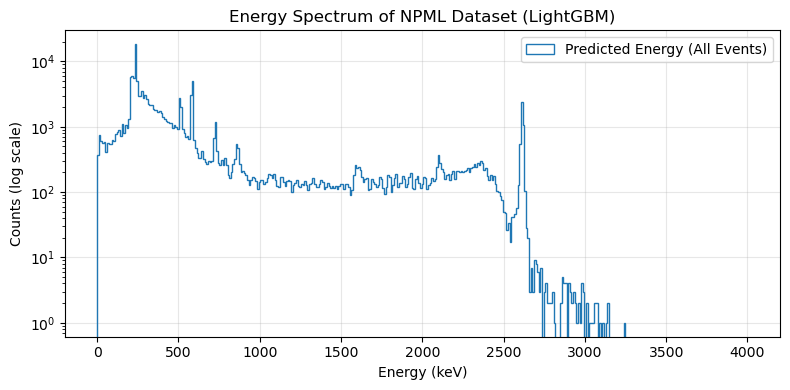

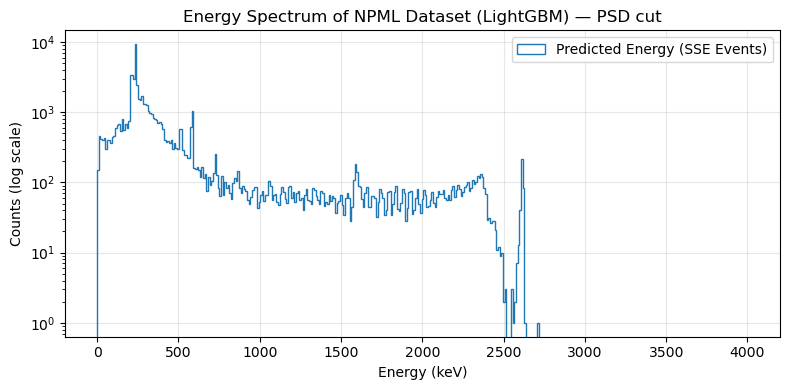

In [18]:
plot_energy_spectrum(pred_df["pred_energy_lightgbm_npml"], model="LightGBM")

lgbm_energy_cuts = pred_df[pred_df["SSE"] == 1]["pred_energy_lightgbm_npml"]
plot_energy_spectrum(lgbm_energy_cuts, model="LightGBM", cut=True)

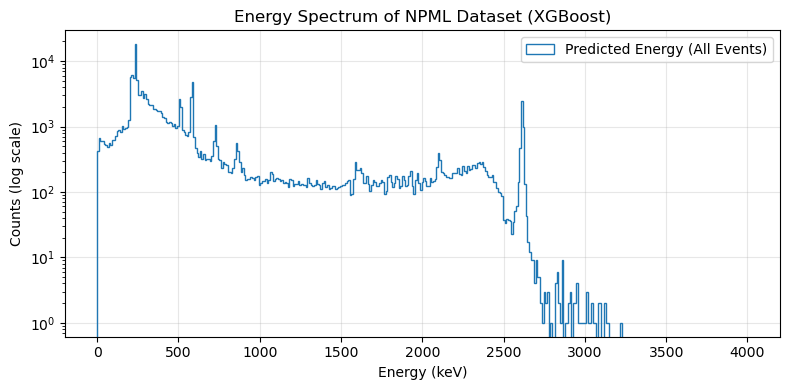

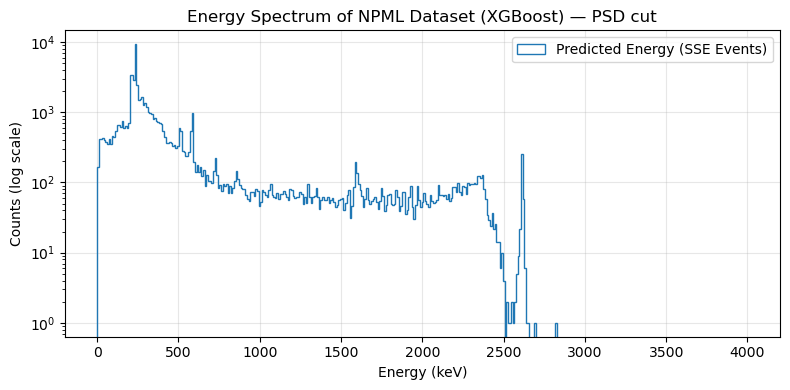

In [19]:
plot_energy_spectrum(pred_df["pred_energy_xgb_npml"], model="XGBoost")

xgb_energy_cuts = pred_df[pred_df["SSE"] == 1]["pred_energy_xgb_npml"]
plot_energy_spectrum(xgb_energy_cuts, model="XGBoost", cut=True)

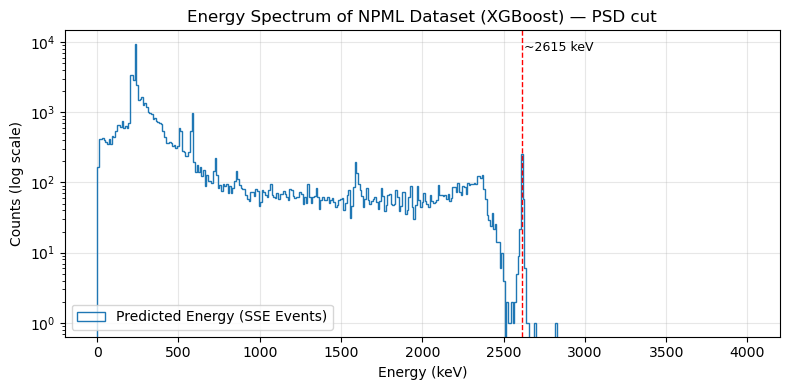

In [24]:
plot_energy_spectrum(xgb_energy_cuts, model="XGBoost", cut=True, add_peaks=True)

## Confusion Matrix on Test Data (All Predicted Classification Labels Combined)

In [45]:
test_df = pd.read_csv("combined_test_with_labels.csv.gz")
test_df

,id,energy_label,psd_label_low_avse,psd_label_high_avse,psd_label_dcr,psd_label_lq,tp0,ED,HWP,LQ80,...,tdrift50,tdrift99,tfr,peak_count,gbn,bpr,AvsE,GradAreaRatio,GradWidthMain,HFER
0,2395098_test_0,1167.174731,True,True,True,True,967,3407.0,2036.0,-1.300536e+06,...,55.0,76.0,0.148591,1,1.282821,0.062497,0.553581,2.257453e+02,69.0,0.034373
1,2395099_test_0,870.765543,False,True,True,False,960,3405.0,2019.0,-9.729822e+05,...,70.0,90.0,0.147334,1,1.203640,0.063886,0.573090,2.120524e+12,88.0,0.034307
2,2395100_test_0,582.980526,False,True,True,True,960,3412.0,2107.0,-6.390870e+05,...,76.0,100.0,0.139090,2,1.189320,0.057715,0.443685,1.784824e+02,84.0,0.034885
3,2395101_test_0,238.918902,True,True,True,True,930,3408.0,2053.0,-2.760460e+05,...,88.0,110.0,0.138597,2,1.226275,0.067184,0.583046,1.000000e+00,53.0,0.035474
4,2395102_test_0,214.491195,False,True,True,True,924,3406.0,1939.0,-7.611188e+04,...,83.0,135.0,0.149185,13,1.203153,0.055602,0.403248,1.000000e+00,46.0,0.051582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389995,2785093_test_5,238.472881,False,True,True,False,940,3406.0,2081.0,-2.667054e+05,...,69.0,111.0,0.144375,2,1.198436,0.062338,0.518905,1.000000e+00,73.0,0.034997
389996,2785094_test_5,452.840234,True,True,True,True,952,3406.0,2058.0,-5.194853e+05,...,59.0,83.0,0.148058,3,2.268535,0.064586,0.590262,5.597816e+01,54.0,0.035930
389997,2785095_test_5,344.740556,True,True,True,True,948,3406.0,2036.0,-3.684673e+05,...,80.0,125.0,0.140774,3,1.217066,0.062375,0.536752,1.000000e+00,82.0,0.034713
389998,2785096_test_5,163.807547,True,True,True,True,925,3406.0,2067.0,-1.903450e+05,...,94.0,116.0,0.140754,2,0.975055,0.066704,0.577498,1.000000e+00,41.0,0.036159


In [ ]:
X_test = test_df[feature_cols]

In [71]:
# predict probabilities for test set
test_probs_high_avse = high_avse_xgb.predict_proba(X_test)[:, 1]
test_probs_lq = rf_pipe_lq.predict_proba(X_test)[:, 1]
test_probs_dcr = dcr_nn_pipe.predict_proba(X_test)[:, 1]
test_probs_low_avse = rf_low_avse.predict_proba(X_test)[:, 1]

In [ ]:
# predict all labels on test set
test_pred_high_avse = (test_probs_high_avse >= high_avse_xgb_threshold).astype(int)
test_pred_lq = (test_probs_lq >= best_threshold_lq).astype(int)
test_pred_low_avse = rf_low_avse.predict(X_test).astype(int)
test_pred_dcr = (test_probs_dcr >= 0.5).astype(int)

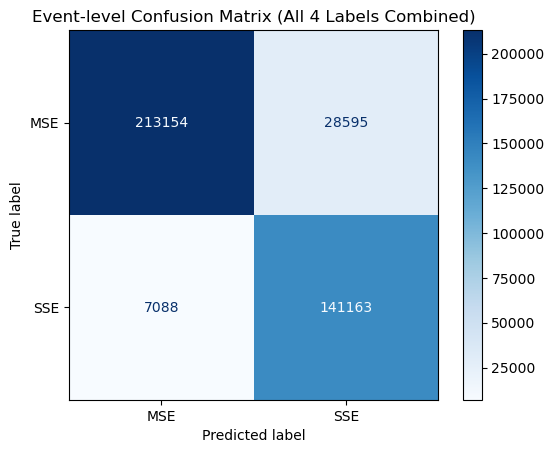

              precision    recall  f1-score   support

         MSE     0.9678    0.8817    0.9228    241749
         SSE     0.8316    0.9522    0.8878    148251

    accuracy                         0.9085    390000
   macro avg     0.8997    0.9170    0.9053    390000
weighted avg     0.9160    0.9085    0.9095    390000



In [ ]:
# combine all 4 predicted labels to get final SSE prediction for test set
y_true_sse = (test_df[classification_label_cols] == 1).all(axis=1).astype(int)
y_pred_sse = (
    (test_pred_lq == 1) &
    (test_pred_high_avse == 1) &
    (test_pred_low_avse == 1) &
    (test_pred_dcr == 1)
).astype(int)

# confusion matrix
cm = confusion_matrix(y_true_sse, y_pred_sse, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["MSE", "SSE"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Event-level Confusion Matrix (All 4 Labels Combined)")
plt.show()

print(classification_report(y_true_sse, y_pred_sse, target_names=["MSE", "SSE"], digits=4))

In [78]:
sse_score_pred = (
    np.asarray(test_probs_high_avse) *
    np.asarray(test_probs_lq) *
    np.asarray(test_probs_low_avse) *
    np.asarray(test_probs_dcr)
)

print("MCC:", matthews_corrcoef(y_true_sse, y_pred_sse))
print("Accuracy:", accuracy_score(y_true_sse, y_pred_sse))
print("Balanced Acc:", balanced_accuracy_score(y_true_sse, y_pred_sse))
print("AUC-ROC:", roc_auc_score(y_true_sse, sse_score_pred))
print("AUC-PR :", average_precision_score(y_true_sse, sse_score_pred))

MCC: 0.8164558861475454
Accuracy: 0.9085051282051282
Balanced Acc: 0.9169526764012886
AUC-ROC: 0.9704931341308707
AUC-PR : 0.9438236453396812


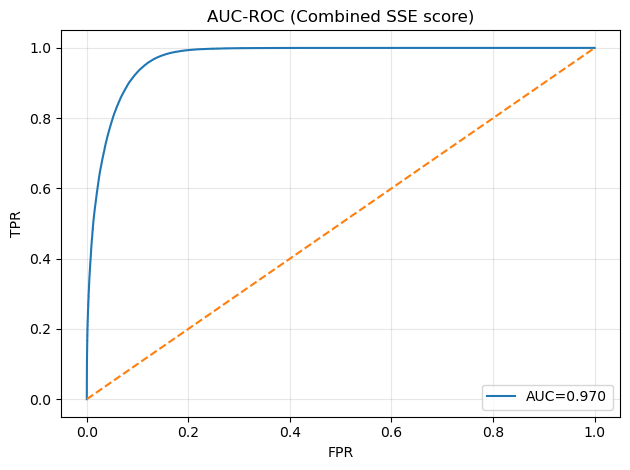

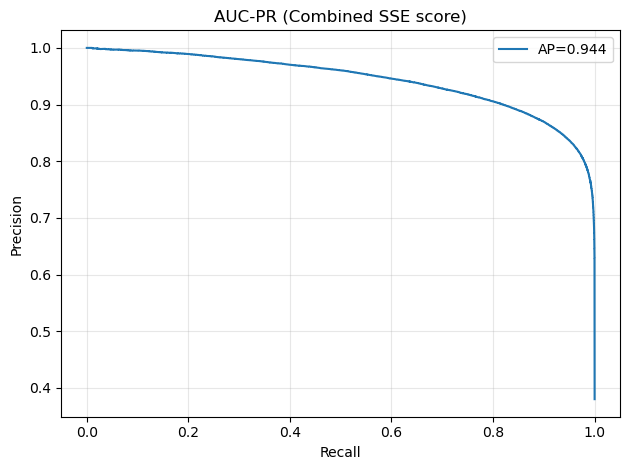

In [77]:
fpr, tpr, _ = roc_curve(y_true_sse, sse_score_pred)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("AUC-ROC (Combined SSE score)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

prec, rec, _ = precision_recall_curve(y_true_sse, sse_score_pred)
plt.figure()
plt.plot(rec, prec, label=f"AP={average_precision_score(y_true_sse, sse_score_pred):.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("AUC-PR (Combined SSE score)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [79]:
# predict energy on test set
test_pred_energy_lgb = lgb_model.predict(X_test)
test_pred_energy_xgb = xgb_regressor_model.predict(X_test)

In [82]:
# combine test predictions and true labels with ids into a dataframe
test_results_df = pd.DataFrame({
    "id": test_df["id"],
    "true_label": y_true_sse,
    "pred_label": y_pred_sse,
    "true_energy": test_df["energy_label"],
    "pred_energy_lightgbm": test_pred_energy_lgb,
    "pred_energy_xgb": test_pred_energy_xgb,
})

test_results_df.to_csv("test_predictions.csv", index=False)